In [2]:
import pandas as pd

df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Shape:", df.shape)
df.head()

Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [5]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


In [6]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,83.877551
Yes,16.122449


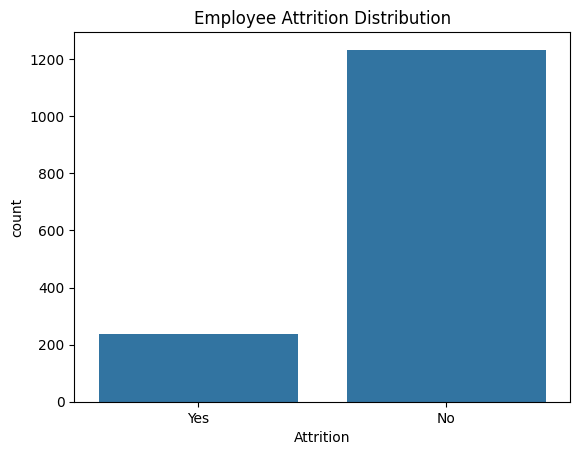

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition Distribution")
plt.show()

In [8]:
df_copy = df.copy()

In [9]:
df_copy["Income_Per_Year"] = df_copy["MonthlyIncome"] / (df_copy["YearsAtCompany"] + 1)

In [10]:
df_copy["Stability_Index"] = df_copy["YearsAtCompany"] / (df_copy["Age"] + 1)

In [11]:
df_copy["WorkPressure"] = df_copy["OverTime"].map({"Yes":1, "No":0}) + (df_copy["JobSatisfaction"])

In [12]:
df_copy["Experience_Ratio"] = df_copy["TotalWorkingYears"] / (df_copy["Age"] + 1)

In [13]:
df_copy.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Income_Per_Year,Stability_Index,WorkPressure,Experience_Ratio
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,0,1,6,4,0,5,856.142857,0.142857,5,0.190476
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,3,3,10,7,1,7,466.363636,0.200000,2,0.200000
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,3,3,0,0,0,0,2090.000000,0.000000,4,0.184211
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,3,8,7,3,0,323.222222,0.235294,4,0.235294
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,3,3,2,2,2,2,1156.000000,0.071429,2,0.214286


In [14]:
numeric_df = df_copy.select_dtypes(include=['int64', 'float64'])

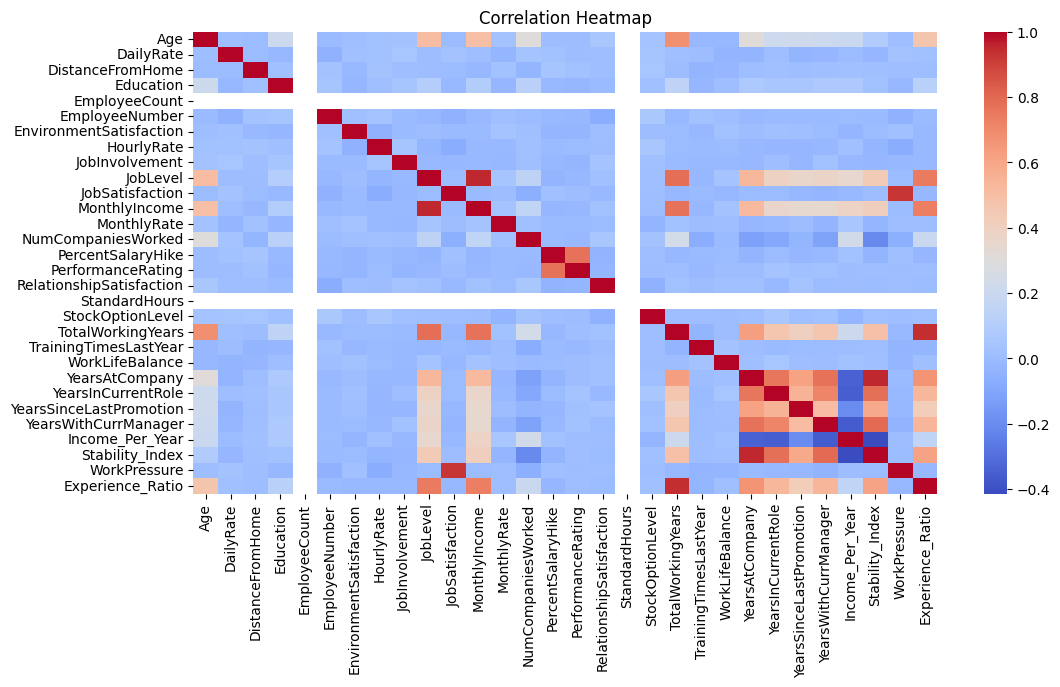

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [16]:
df_copy["Attrition"] = df_copy["Attrition"].map({"Yes": 1, "No": 0})


In [17]:
cat_cols = df_copy.select_dtypes(include="object").columns
print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [18]:
df_encoded = pd.get_dummies(df_copy, drop_first=True)

In [19]:
print(df_encoded.shape)
df_encoded.head()

(1470, 52)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False


In [20]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("Attrition", axis=1)
y = df_encoded["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1176, 51)
(294, 51)
(1176,)
(294,)


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8673469387755102
              precision    recall  f1-score   support

           0       0.87      0.99      0.93       247
           1       0.83      0.21      0.34        47

    accuracy                           0.87       294
   macro avg       0.85      0.60      0.63       294
weighted avg       0.86      0.87      0.83       294



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8299319727891157
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8435374149659864
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.70      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:45:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


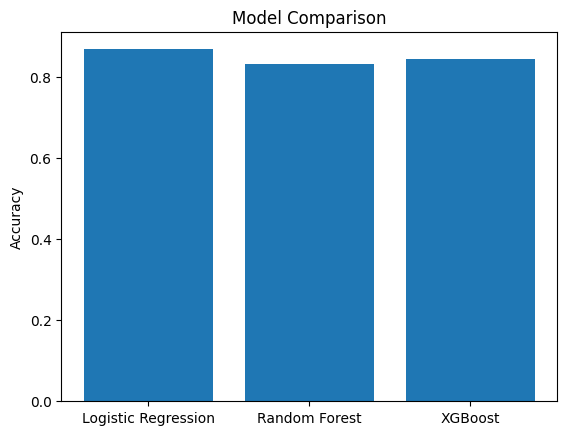

In [25]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

import matplotlib.pyplot as plt

plt.bar(models, accuracies)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

print(cm)

[[237  10]
 [ 36  11]]


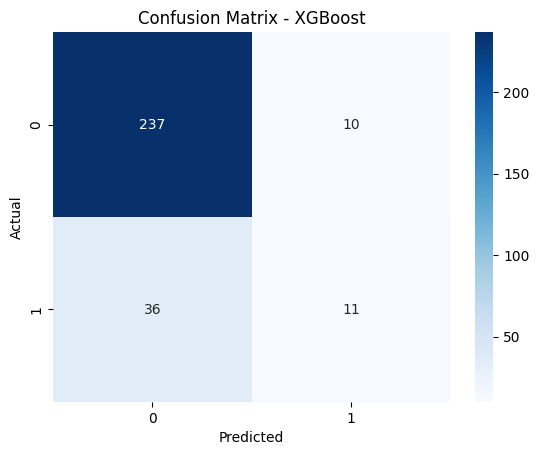

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [28]:
from sklearn.metrics import roc_auc_score

roc_score = roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1])

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.7670772676371781


In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.52      0.23      0.32        47

    accuracy                           0.84       294
   macro avg       0.70      0.60      0.62       294
weighted avg       0.81      0.84      0.82       294



In [30]:
!pip install shap

In [31]:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

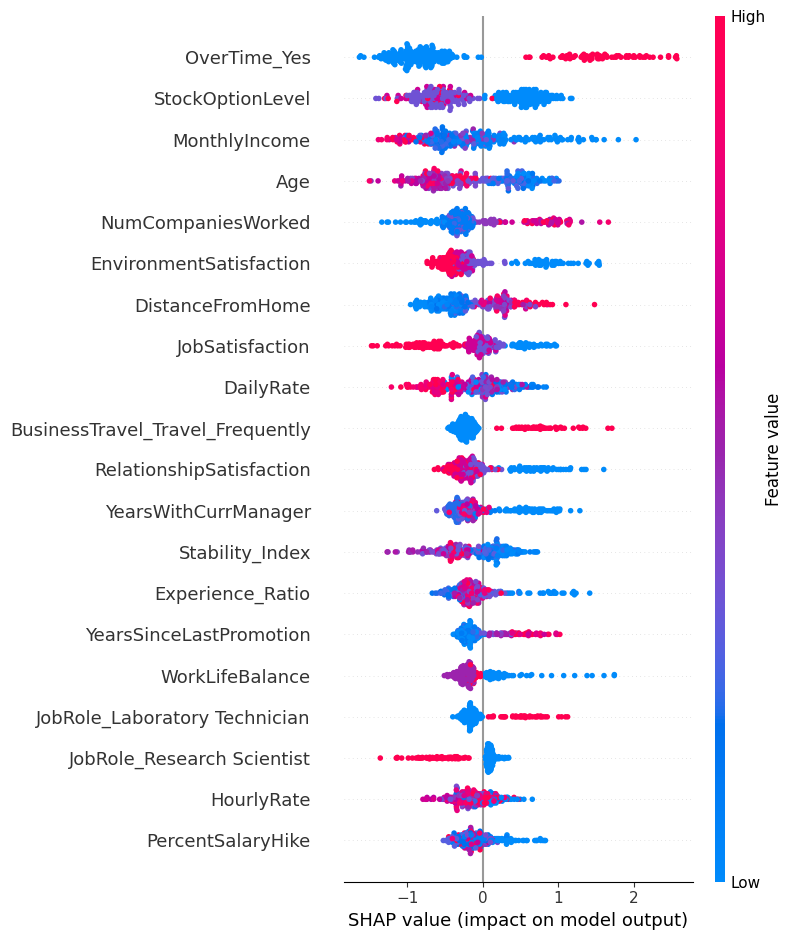

In [32]:
shap.summary_plot(shap_values, X_test)

In [33]:
shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [34]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=42),
    params,
    cv=5,
    scoring='f1',
    n_iter=10
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
print(search.best_params_)

{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1}


In [35]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring='f1'
)

print("Mean F1 Score:", scores.mean())

Mean F1 Score: 0.466144877506039


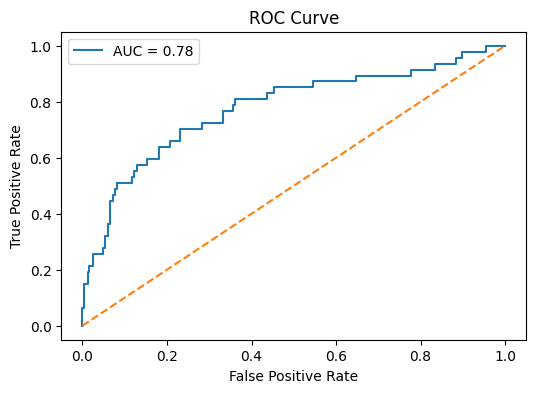

In [36]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
y_prob = best_model.predict_proba(X_test)[:,1]

risk_level = []

for p in y_prob:
    if p < 0.3:
        risk_level.append("Low")
    elif p < 0.7:
        risk_level.append("Medium")
    else:
        risk_level.append("High")

In [38]:
results = X_test.copy()

results["Actual_Attrition"] = y_test.values
results["Attrition_Probability"] = y_prob
results["Risk_Level"] = risk_level

results.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Actual_Attrition,Attrition_Probability,Risk_Level
1061,24,830,13,2,1,1495,4,78,3,1,...,False,False,False,True,True,False,False,0,0.555288,Medium
891,44,1117,2,1,1,1246,1,72,4,1,...,False,True,False,False,True,False,False,0,0.031271,Low
456,31,688,7,3,1,613,3,44,2,3,...,False,False,False,False,False,False,False,0,0.132056,Low
922,44,1199,4,2,1,1288,3,92,4,5,...,False,False,False,False,False,False,False,0,0.009950,Low
69,36,318,9,3,1,90,4,79,2,1,...,False,True,False,False,True,False,True,1,0.097415,Low


In [39]:
results["Risk_Level"].value_counts()

,count
Risk_Level,
Low,252
Medium,34
High,8


In [40]:
results.to_csv("RetainX_Risk_Analysis.csv", index=False)

In [41]:
from google.colab import files

files.download("RetainX_Risk_Analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
results["Recommendation"] = results["Risk_Level"].map({
    "High": "Immediate HR Intervention",
    "Medium": "Monitor Employee",
    "Low": "Normal Retention Program"
})

results.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,Actual_Attrition,Attrition_Probability,Risk_Level,Recommendation
1061,24,830,13,2,1,1495,4,78,3,1,...,False,False,True,True,False,False,0,0.555288,Medium,Monitor Employee
891,44,1117,2,1,1,1246,1,72,4,1,...,True,False,False,True,False,False,0,0.031271,Low,Normal Retention Program
456,31,688,7,3,1,613,3,44,2,3,...,False,False,False,False,False,False,0,0.132056,Low,Normal Retention Program
922,44,1199,4,2,1,1288,3,92,4,5,...,False,False,False,False,False,False,0,0.009950,Low,Normal Retention Program
69,36,318,9,3,1,90,4,79,2,1,...,True,False,False,True,False,True,1,0.097415,Low,Normal Retention Program


In [43]:
results.to_csv("RetainX_Final_Output.csv", index=False)

In [44]:
from google.colab import files

files.download("RetainX_Final_Output.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>